# 04 Machine Learning Model Benchmark

This notebook benchmarks multiple machine learning models for webcam-based PM₂.₅ estimation using the optimal feature set developed in the previous notebook.

A unified benchmarking framework is adopted to compare predictive performance, generalisation ability, and computational efficiency across models with different levels of complexity, aiming to identify the most suitable model for the proposed hybrid PM₂.₅ estimation framework.

**Input:** `data/processed/final_dataset.csv`

**Output:** `results/model_benchmark/`

## Workflow Overview

1. Dataset and benchmark setup
2. Benchmark model definition
3. Model benchmarking
4. Performance evaluation
5. Prediction diagnostics
6. Computational efficiency



## Setup

In [69]:
# Standard library
import sys
import importlib
from pathlib import Path

# Project path
PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Data processing
import numpy as np
import pandas as pd

# Visualisation
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

# Project modules
import src.config as config
import src.models.benchmark as benchmark
import src.models.benchmark_plots as benchmark_plots

# Reload project modules during notebook development
config = importlib.reload(config)
benchmark = importlib.reload(benchmark)
benchmark_plots = importlib.reload(benchmark_plots)

# Plot settings
plt.style.use("default")
sns.set_theme(style="whitegrid")

mpl.rcParams.update(
    {
        "font.family": "Times New Roman",
        "font.size": 11,
    }
)

# Results directory
RESULTS_DIR = PROJECT_ROOT / "results" / "model_benchmark"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Results directory: {RESULTS_DIR}")

Project root: /Users/qingxuan/Desktop/webcam-pm25-toolbox
Results directory: /Users/qingxuan/Desktop/webcam-pm25-toolbox/results/model_benchmark


## 1 Dataset and Benchmark Setup

### 1.1 Dataset and Feature Set

Load the final processed dataset used for machine learning model benchmarking.

The benchmark is based on the optimal feature set selected in the previous notebook, including image, meteorological, and temporal features.

In [12]:
# Load the final processed dataset
DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "final_dataset.csv"
)

df = pd.read_csv(
    DATA_PATH,
    parse_dates=["time"],
)

# Define target and predictor variables
TARGET = config.TARGET
FEATURES = config.ALL_FEATURES

# Columns required for model benchmarking
benchmark_columns = [
    "time",
    TARGET,
    *FEATURES,
]

# Validate required columns
missing_columns = [
    column
    for column in benchmark_columns
    if column not in df.columns
]

if missing_columns:
    raise ValueError(
        "Missing required columns in the dataset: "
        f"{missing_columns}"
    )

# Prepare complete-case benchmark dataset
benchmark_df = (
    df.loc[:, benchmark_columns]
    .dropna()
    .sort_values("time")
    .reset_index(drop=True)
)

if benchmark_df.empty:
    raise ValueError(
        "No complete samples are available for benchmarking."
    )

# Dataset information
total_samples = len(df)
benchmark_samples = len(benchmark_df)
removed_samples = total_samples - benchmark_samples

start_time = benchmark_df["time"].min()
end_time = benchmark_df["time"].max()

# Dataset summary
dataset_summary = pd.DataFrame(
    {
        "Item": [
            "Input dataset",
            "Total samples",
            "Benchmark samples",
            "Rows removed due to missing values",
            "Time range",
            "Target variable",
            "Number of predictors",
        ],
        "Value": [
            DATA_PATH.name,
            f"{total_samples:,}",
            f"{benchmark_samples:,}",
            f"{removed_samples:,}",
            (
                f"{start_time:%Y-%m-%d %H:%M} to "
                f"{end_time:%Y-%m-%d %H:%M}"
            ),
            TARGET,
            len(FEATURES),
        ],
    }
)

display(dataset_summary)

,Item,Value
0,Input dataset,final_dataset.csv
1,Total samples,"2,581"
2,Benchmark samples,"2,581"
3,Rows removed due to missing values,0
4,Time range,2026-03-03 03:00 to 2026-07-17 11:00
5,Target variable,PM25
6,Number of predictors,50


In [13]:
# Define feature groups
feature_groups = {
    "Image": config.IMAGE_FEATURES,
    "ERA5": config.ERA5_FEATURES,
    "ARPA": config.ARPA_FEATURES,
    "Temporal": config.TEMPORAL_FEATURES,
}

# Combine features from all groups
grouped_features = [
    feature
    for features in feature_groups.values()
    for feature in features
]

# Validate feature configuration
duplicate_features = sorted(
    {
        feature
        for feature in grouped_features
        if grouped_features.count(feature) > 1
    }
)

missing_from_groups = sorted(
    set(FEATURES) - set(grouped_features)
)

extra_group_features = sorted(
    set(grouped_features) - set(FEATURES)
)

if duplicate_features:
    raise ValueError(
        "Features assigned to multiple groups: "
        f"{duplicate_features}"
    )

if missing_from_groups:
    raise ValueError(
        "Features in ALL_FEATURES but not assigned "
        f"to a feature group: {missing_from_groups}"
    )

if extra_group_features:
    raise ValueError(
        "Grouped features not included in ALL_FEATURES: "
        f"{extra_group_features}"
    )

# Feature group summary
feature_group_summary = pd.DataFrame(
    {
        "Feature Group": [
            *feature_groups.keys(),
            "Total",
        ],
        "Number of Features": [
            *[
                len(features)
                for features in feature_groups.values()
            ],
            len(FEATURES),
        ],
    }
)

display(feature_group_summary)

,Feature Group,Number of Features
0,Image,18
1,ERA5,19
2,ARPA,6
3,Temporal,7
4,Total,50


### 1.2 Benchmark Protocol

Machine learning models are evaluated using a random hold-out strategy.

The dataset is randomly split into a development set and an independent test set. The development set is used for model training and five-fold cross-validation, while the independent test set is reserved for the final model evaluation.

The benchmark protocol consists of:

- 80% development data and 20% independent test data
- Five-fold shuffled cross-validation on the development set
- A fixed random seed for reproducibility
- R², RMSE, and MAE as evaluation metrics

In [14]:
# Benchmark configuration
TEST_SIZE = 0.20
N_SPLITS = 5
RANDOM_STATE = 42

EVALUATION_METRICS = [
    "R²",
    "RMSE",
    "MAE",
]

# Validate benchmark settings
if not 0 < TEST_SIZE < 1:
    raise ValueError(
        "TEST_SIZE must be between 0 and 1."
    )

if N_SPLITS < 2:
    raise ValueError(
        "N_SPLITS must be at least 2."
    )

# Benchmark protocol summary
protocol_summary = pd.DataFrame(
    {
        "Setting": [
            "Splitting strategy",
            "Development set",
            "Independent test set",
            "Cross-validation",
            "CV shuffling",
            "Random seed",
            "Evaluation metrics",
        ],
        "Value": [
            "Random hold-out split",
            f"{(1 - TEST_SIZE) * 100:.0f}%",
            f"{TEST_SIZE * 100:.0f}%",
            f"{N_SPLITS}-fold",
            "Yes",
            RANDOM_STATE,
            ", ".join(EVALUATION_METRICS),
        ],
    }
)

display(protocol_summary)

,Setting,Value
0,Splitting strategy,Random hold-out split
1,Development set,80%
2,Independent test set,20%
3,Cross-validation,5-fold
4,CV shuffling,Yes
5,Random seed,42
6,Evaluation metrics,"R², RMSE, MAE"


In [15]:
# Create development and independent test sets
development_df, test_df = benchmark.random_split(
    df=benchmark_df,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)

# Validate the split
if development_df.empty or test_df.empty:
    raise ValueError(
        "The development or independent test set is empty."
    )

if len(development_df) + len(test_df) != len(benchmark_df):
    raise ValueError(
        "The split sample counts do not match "
        "the full benchmark dataset."
    )

# Split summary
split_summary = pd.DataFrame(
    {
        "Subset": [
            "Full benchmark dataset",
            "Development set",
            "Independent test set",
        ],
        "Samples": [
            len(benchmark_df),
            len(development_df),
            len(test_df),
        ],
        "Percentage": [
            100.0,
            (
                len(development_df)
                / len(benchmark_df)
                * 100
            ),
            (
                len(test_df)
                / len(benchmark_df)
                * 100
            ),
        ],
    }
)

split_summary["Percentage"] = (
    split_summary["Percentage"]
    .map(lambda value: f"{value:.1f}%")
)

display(split_summary)

,Subset,Samples,Percentage
0,Full benchmark dataset,2581,100.0%
1,Development set,2064,80.0%
2,Independent test set,517,20.0%


In [16]:
# Compare PM2.5 distributions between subsets
target_distribution_summary = pd.DataFrame(
    {
        "Subset": [
            "Development set",
            "Independent test set",
        ],
        "Samples": [
            len(development_df),
            len(test_df),
        ],
        "Mean": [
            development_df[TARGET].mean(),
            test_df[TARGET].mean(),
        ],
        "Standard Deviation": [
            development_df[TARGET].std(),
            test_df[TARGET].std(),
        ],
        "Minimum": [
            development_df[TARGET].min(),
            test_df[TARGET].min(),
        ],
        "Median": [
            development_df[TARGET].median(),
            test_df[TARGET].median(),
        ],
        "Maximum": [
            development_df[TARGET].max(),
            test_df[TARGET].max(),
        ],
    }
).round(2)

display(target_distribution_summary)

,Subset,Samples,Mean,Standard Deviation,Minimum,Median,Maximum
0,Development set,2064,13.42,11.00,0.41,10.15,75.18
1,Independent test set,517,13.27,10.85,0.33,10.48,64.35


### 1.3 Benchmark Models

Five regression models representing different levels of model complexity were selected for benchmarking.

The benchmark covers linear, tree-based, ensemble, and neural network approaches.

In [20]:
# Define benchmark models
benchmark_models = benchmark.get_benchmark_models(
    random_state=RANDOM_STATE,
)

# Benchmark model summary
model_summary = pd.DataFrame(
    {
        "Model": [
            "Ridge Regression",
            "Decision Tree",
            "Random Forest",
            "Gradient Boosting",
            "MLP",
        ],
        "Category": [
            "Linear",
            "Tree-based",
            "Ensemble",
            "Ensemble",
            "Neural Network",
        ],
        "Description": [
            "Linear regression with L2 regularisation",
            "Single decision tree",
            "Bagging ensemble of decision trees",
            "Boosting ensemble of decision trees",
            "Feed-forward neural network",
        ],
        "Complexity": [
            "Low",
            "Low",
            "Medium",
            "Medium",
            "High",
        ],
    }
)

display(model_summary)

,Model,Category,Description,Complexity
0,Ridge Regression,Linear,Linear regression with L2 regularisation,Low
1,Decision Tree,Tree-based,Single decision tree,Low
2,Random Forest,Ensemble,Bagging ensemble of decision trees,Medium
3,Gradient Boosting,Ensemble,Boosting ensemble of decision trees,Medium
4,MLP,Neural Network,Feed-forward neural network,High


## 2 Model Benchmarking

### 2.1 Benchmark Execution

Run the benchmark for all regression models using the predefined benchmark protocol.

The benchmark produces cross-validation results, independent test performance, prediction outputs, residuals, and computational efficiency statistics for subsequent analysis.

In [ ]:
# Run the model benchmark
benchmark_results, fold_results, fitted_models, predictions = (
    benchmark.benchmark_models(
        models=benchmark_models,
        development_df=development_df,
        test_df=test_df,
        features=FEATURES,
        target=TARGET,
        n_splits=N_SPLITS,
        random_state=RANDOM_STATE,
    )
)

# Benchmark execution summary
execution_summary = pd.DataFrame(
    {
        "Item": [
            "Benchmark status",
            "Models evaluated",
            "Development samples",
            "Independent test samples",
            "Predictors",
            "Cross-validation",
        ],
        "Value": [
            "Completed",
            len(benchmark_results),
            f"{len(development_df):,}",
            f"{len(test_df):,}",
            len(FEATURES),
            f"{N_SPLITS}-fold shuffled CV",
        ],
    }
)

display(execution_summary)

,Item,Value
0,Benchmark status,Completed
1,Models evaluated,5
2,Development samples,"2,064"
3,Independent test samples,517
4,Predictors,50
5,Cross-validation,5-fold shuffled


### 2.2 Cross-Validation Performance

Cross-validation performance on the development set is used to compare the predictive accuracy and stability of the benchmark models.

Mean R² and RMSE are reported across the five validation folds together with their standard deviations.

In [22]:
# Summarise cross-validation performance
cv_columns = [
    "Model",
    "CV R2",
    "CV R2 Std",
    "CV RMSE",
    "CV RMSE Std",
    "CV MAE",
    "CV MAE Std",
]

cv_summary = (
    benchmark_results.loc[:, cv_columns]
    .sort_values(
        by="CV R2",
        ascending=False,
    )
    .reset_index(drop=True)
)

# Add ranking
cv_summary.insert(
    0,
    "Rank",
    range(1, len(cv_summary) + 1),
)

# Format numeric results for display
cv_summary_display = cv_summary.copy()

numeric_columns = [
    column
    for column in cv_summary_display.columns
    if column not in ["Rank", "Model"]
]

cv_summary_display[numeric_columns] = (
    cv_summary_display[numeric_columns]
    .round(3)
)

display(cv_summary_display)

,Rank,Model,CV R2,CV R2 Std,CV RMSE,CV RMSE Std,CV MAE,CV MAE Std
0,1,Gradient Boosting,0.815,0.042,4.704,0.509,3.403,0.202
1,2,MLP,0.801,0.023,4.886,0.278,3.528,0.084
2,3,Random Forest,0.794,0.046,4.963,0.549,3.631,0.221
3,4,Decision Tree,0.718,0.033,5.830,0.446,4.185,0.281
4,5,Ridge,0.658,0.033,6.405,0.177,4.848,0.056


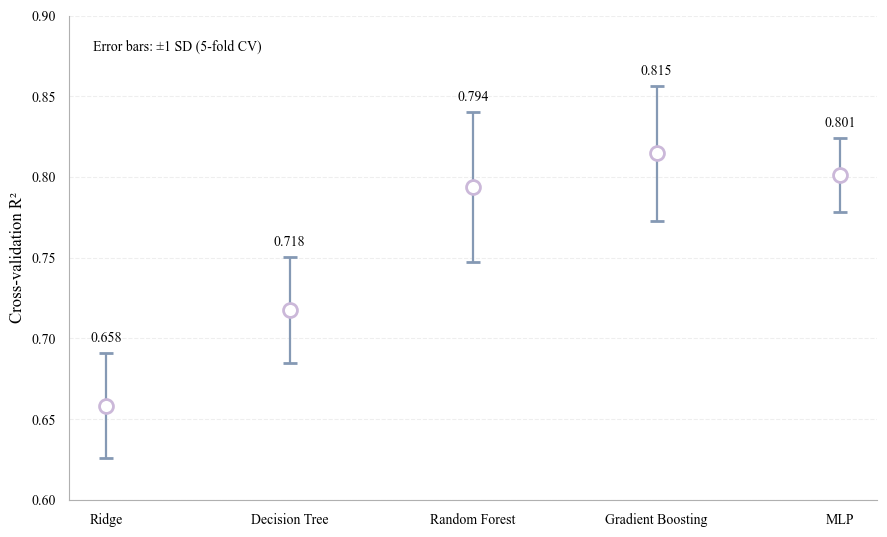

Figure saved to: /Users/qingxuan/Desktop/webcam-pm25-toolbox/results/model_benchmark/cross_validation_performance.png


In [286]:
# Figure 1: Cross-validation R² performance
fig_1, ax_1 = (
    benchmark_plots.plot_cross_validation_benchmark(
        benchmark_results=benchmark_results,
        output_path=(
            RESULTS_DIR
            / "cross_validation_performance.png"
        ),
        model_order=[
            "Ridge",
            "Decision Tree",
            "Random Forest",
            "Gradient Boosting",
            "MLP",
        ],
        figure_size=(9, 5.5),
        point_color="#CBB8D9",
        error_color="#8599B4",
        marker_size=10,
        dpi=300,
    )
)

### 2.3 Independent Test Performance

Independent test performance is used to evaluate the generalisation ability of the benchmark models.

R², RMSE, and MAE are reported on the independent test set for comparison across all benchmark models.

In [23]:
# Summarise independent test performance
test_columns = [
    "Model",
    "Test R2",
    "Test RMSE",
    "Test MAE",
]

test_summary = (
    benchmark_results.loc[:, test_columns]
    .sort_values(
        by="Test R2",
        ascending=False,
    )
    .reset_index(drop=True)
)

# Add ranking
test_summary.insert(
    0,
    "Rank",
    range(1, len(test_summary) + 1),
)

# Format metrics for display
metric_columns = [
    "Test R2",
    "Test RMSE",
    "Test MAE",
]

test_summary_display = test_summary.copy()

test_summary_display[metric_columns] = (
    test_summary_display[metric_columns]
    .round(3)
)

display(test_summary_display)

,Rank,Model,Test R2,Test RMSE,Test MAE
0,1,MLP,0.816,4.654,3.457
1,2,Gradient Boosting,0.810,4.728,3.493
2,3,Random Forest,0.790,4.970,3.674
3,4,Decision Tree,0.722,5.721,4.062
4,5,Ridge,0.617,6.710,5.104


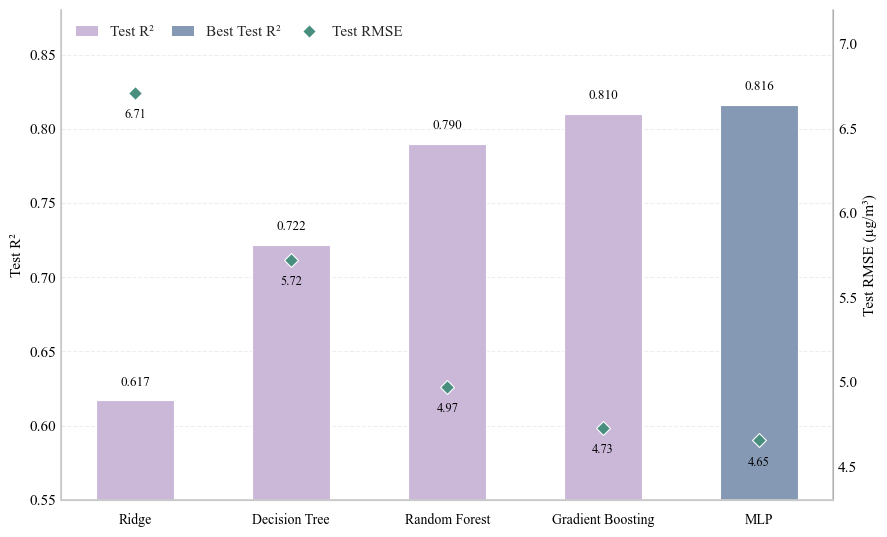

Figure saved to: /Users/qingxuan/Desktop/webcam-pm25-toolbox/results/model_benchmark/independent_test_performance.png


In [24]:
# Figure 2: Independent test performance
fig_2, ax_2_r2, ax_2_rmse = (
    benchmark_plots.plot_heldout_test_performance(
        benchmark_results=benchmark_results,
        output_path=(
            RESULTS_DIR
            / "independent_test_performance.png"
        ),
        model_order=[
            "Ridge",
            "Decision Tree",
            "Random Forest",
            "Gradient Boosting",
            "MLP",
        ],
        figure_size=(9, 5.5),
        r2_color="#CBB8D9",
        best_color="#8599B4",
        rmse_color="#478E7F",
        dpi=300,
    )
)

### 2.4 Cross-Validation versus Independent Test

Cross-validation and independent test performance are compared to assess the generalisation ability of the benchmark models.

The generalisation gap is calculated as:

$$
\mathrm{Generalisation\ Gap}
=
R_{\mathrm{CV}}^{2}
-
R_{\mathrm{Test}}^{2}
$$

A smaller absolute gap indicates more consistent performance between cross-validation and the independent test set.

In [25]:
# Calculate generalisation gaps
generalisation_summary = benchmark_results[
    [
        "Model",
        "CV R2",
        "Test R2",
    ]
].copy()

generalisation_summary["R2 Gap"] = (
    generalisation_summary["CV R2"]
    - generalisation_summary["Test R2"]
)

generalisation_summary["Absolute R2 Gap"] = (
    generalisation_summary["R2 Gap"].abs()
)

# Rank models by independent test R²
generalisation_summary = (
    generalisation_summary
    .sort_values(
        by="Test R2",
        ascending=False,
    )
    .reset_index(drop=True)
)

generalisation_summary.insert(
    0,
    "Rank",
    range(1, len(generalisation_summary) + 1),
)

# Format results for display
generalisation_display = generalisation_summary[
    [
        "Rank",
        "Model",
        "CV R2",
        "Test R2",
        "R2 Gap",
    ]
].copy()

metric_columns = [
    "CV R2",
    "Test R2",
    "R2 Gap",
]

generalisation_display[metric_columns] = (
    generalisation_display[metric_columns]
    .round(3)
)

display(generalisation_display)

,Rank,Model,CV R2,Test R2,R2 Gap
0,1,MLP,0.801,0.816,-0.014
1,2,Gradient Boosting,0.815,0.810,0.005
2,3,Random Forest,0.794,0.790,0.004
3,4,Decision Tree,0.718,0.722,-0.004
4,5,Ridge,0.658,0.617,0.041


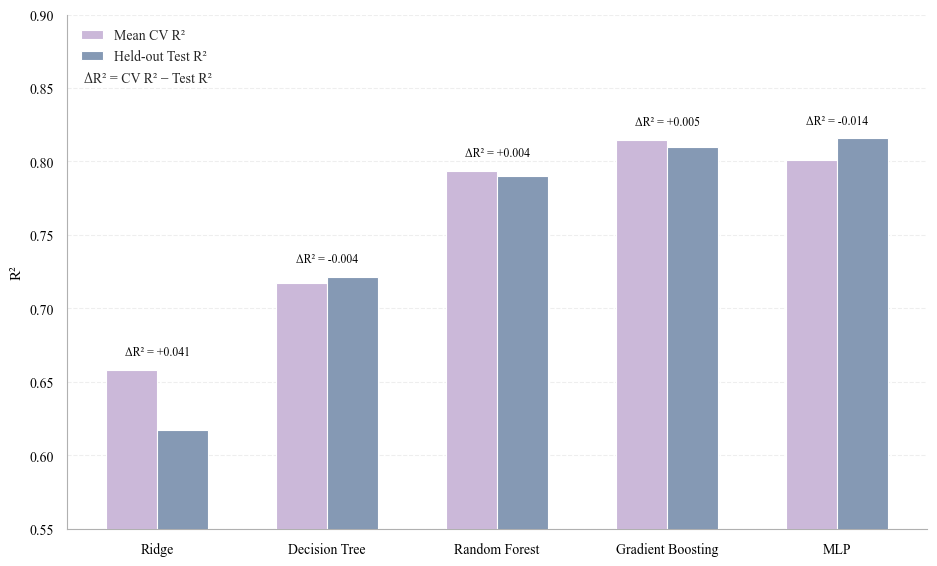

Figure saved to: /Users/qingxuan/Desktop/webcam-pm25-toolbox/results/model_benchmark/cv_vs_independent_test_comparison.png


In [26]:
# Figure 3: Cross-validation versus independent test R²
fig_3, ax_3 = (
    benchmark_plots.plot_cv_test_comparison(
        benchmark_results=benchmark_results,
        output_path=(
            RESULTS_DIR
            / "cv_vs_independent_test_comparison.png"
        ),
        model_order=[
            "Ridge",
            "Decision Tree",
            "Random Forest",
            "Gradient Boosting",
            "MLP",
        ],
        figure_size=(9.5, 5.8),
        cv_color="#CBB8D9",
        test_color="#8599B4",
        bar_width=0.30,
        dpi=300,
    )
)

### 2.5 Overall Performance Ranking

The benchmark models are ranked primarily by independent test performance, with cross-validation results and the generalisation gap retained as complementary indicators.

The ranking considers independent test R², RMSE, MAE, and the R² generalisation gap.

In [27]:
# Create the overall model performance ranking
ranking_columns = [
    "Model",
    "CV R2",
    "Test R2",
    "Test RMSE",
    "Test MAE",
]

overall_ranking = benchmark_results.loc[
    :,
    ranking_columns,
].copy()

# Calculate the generalisation gap
overall_ranking["R2 Gap"] = (
    overall_ranking["CV R2"]
    - overall_ranking["Test R2"]
)

# Rank primarily by independent test performance
overall_ranking = (
    overall_ranking
    .sort_values(
        by=[
            "Test R2",
            "Test RMSE",
            "Test MAE",
        ],
        ascending=[
            False,
            True,
            True,
        ],
    )
    .reset_index(drop=True)
)

overall_ranking.insert(
    0,
    "Rank",
    range(1, len(overall_ranking) + 1),
)

overall_ranking = overall_ranking[
    [
        "Rank",
        "Model",
        "CV R2",
        "Test R2",
        "R2 Gap",
        "Test RMSE",
        "Test MAE",
    ]
]

# Format results for display
overall_ranking_display = overall_ranking.copy()

metric_columns = [
    "CV R2",
    "Test R2",
    "R2 Gap",
    "Test RMSE",
    "Test MAE",
]

overall_ranking_display[metric_columns] = (
    overall_ranking_display[metric_columns]
    .round(3)
)

display(overall_ranking_display)

,Rank,Model,CV R2,Test R2,R2 Gap,Test RMSE,Test MAE
0,1,MLP,0.801,0.816,-0.014,4.654,3.457
1,2,Gradient Boosting,0.815,0.810,0.005,4.728,3.493
2,3,Random Forest,0.794,0.790,0.004,4.970,3.674
3,4,Decision Tree,0.718,0.722,-0.004,5.721,4.062
4,5,Ridge,0.658,0.617,0.041,6.710,5.104


In [28]:
# Extract the top-ranked model
top_model = overall_ranking.iloc[0]
BEST_MODEL_NAME = top_model["Model"]

top_model_summary = pd.DataFrame(
    {
        "Item": [
            "Top-ranked model",
            "Independent test R²",
            "Independent test RMSE",
            "Independent test MAE",
            "R² generalisation gap",
        ],
        "Value": [
            BEST_MODEL_NAME,
            f"{top_model['Test R2']:.3f}",
            f"{top_model['Test RMSE']:.3f} µg/m³",
            f"{top_model['Test MAE']:.3f} µg/m³",
            f"{top_model['R2 Gap']:+.3f}",
        ],
    }
)

display(top_model_summary)

,Item,Value
0,Top-ranked model,MLP
1,Independent test R²,0.816
2,Independent test RMSE,4.654 µg/m³
3,Independent test MAE,3.457 µg/m³
4,R² generalisation gap,-0.014


## 3 Prediction Diagnostics

### 3.1 Prediction Scatter

Observed and predicted PM₂.₅ concentrations are compared for all benchmark models using the independent test set.

The scatter plots provide a visual comparison of prediction accuracy and error patterns across models.

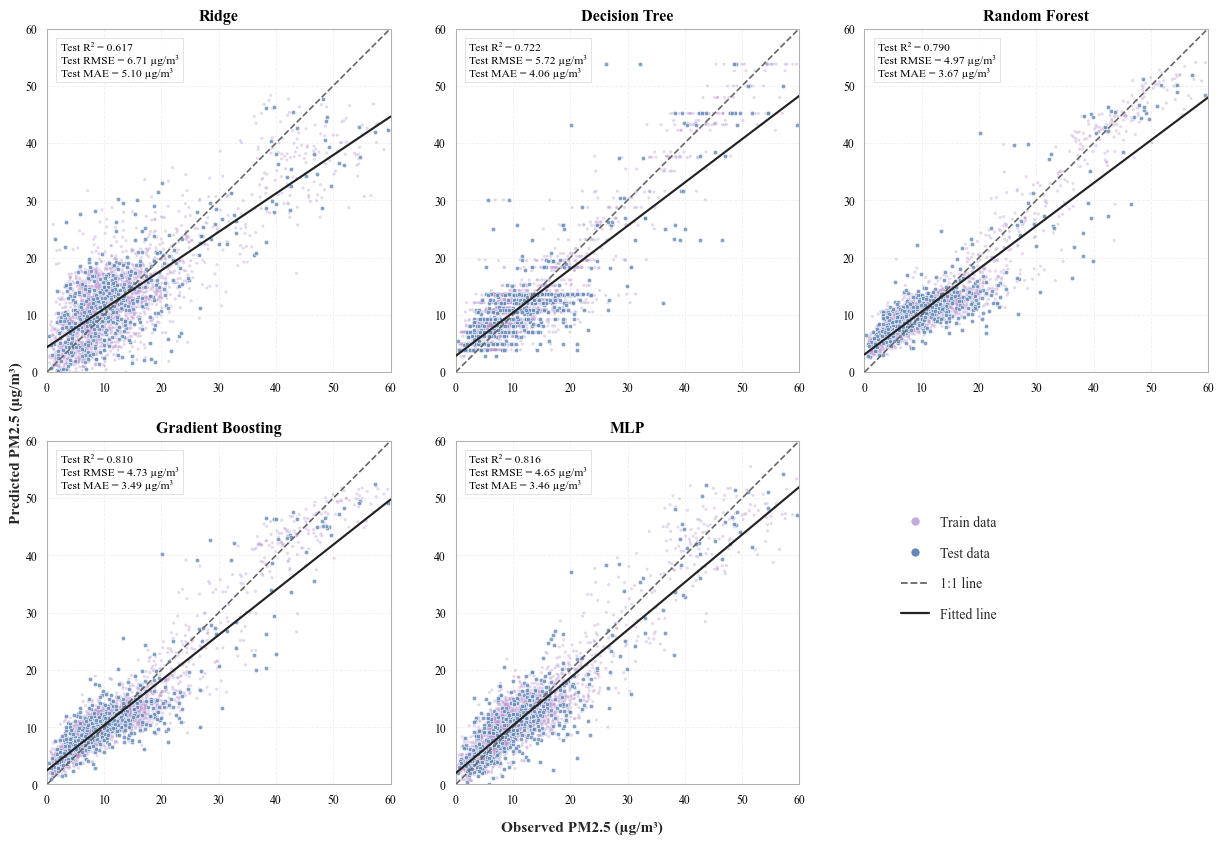

Figure saved to: /Users/qingxuan/Desktop/webcam-pm25-toolbox/results/model_benchmark/prediction_scatter_all_models.png


In [29]:
# Figure 4: Prediction scatter across benchmark models
fig_4, axes_4 = (
    benchmark_plots.plot_all_model_predictions(
        predictions=predictions,
        fitted_models=fitted_models,
        development_df=development_df,
        features=FEATURES,
        target=TARGET,
        benchmark_results=benchmark_results,
        output_path=(
            RESULTS_DIR
            / "prediction_scatter_all_models.png"
        ),
        model_order=[
            "Ridge",
            "Decision Tree",
            "Random Forest",
            "Gradient Boosting",
            "MLP",
        ],
        figure_size=(13, 9),
        train_color="#B48ECF",
        test_color="#6489B9",
        train_point_size=5,
        test_point_size=10,
        train_alpha=0.35,
        test_alpha=0.80,
        dpi=300,
    )
)

### 3.2 Best-performing Model Diagnostics

The top-ranked model is examined in greater detail using observed–predicted relationships, marginal distributions, and residual analysis.

These diagnostics provide a more detailed assessment of prediction accuracy, error distribution, and potential systematic bias.

In [30]:
# Retrieve the top-ranked model
best_model_name = BEST_MODEL_NAME

best_model_metrics = (
    benchmark_results.loc[
        benchmark_results["Model"] == best_model_name
    ]
    .iloc[0]
)

best_model = fitted_models[best_model_name]
best_model_predictions = predictions[best_model_name]

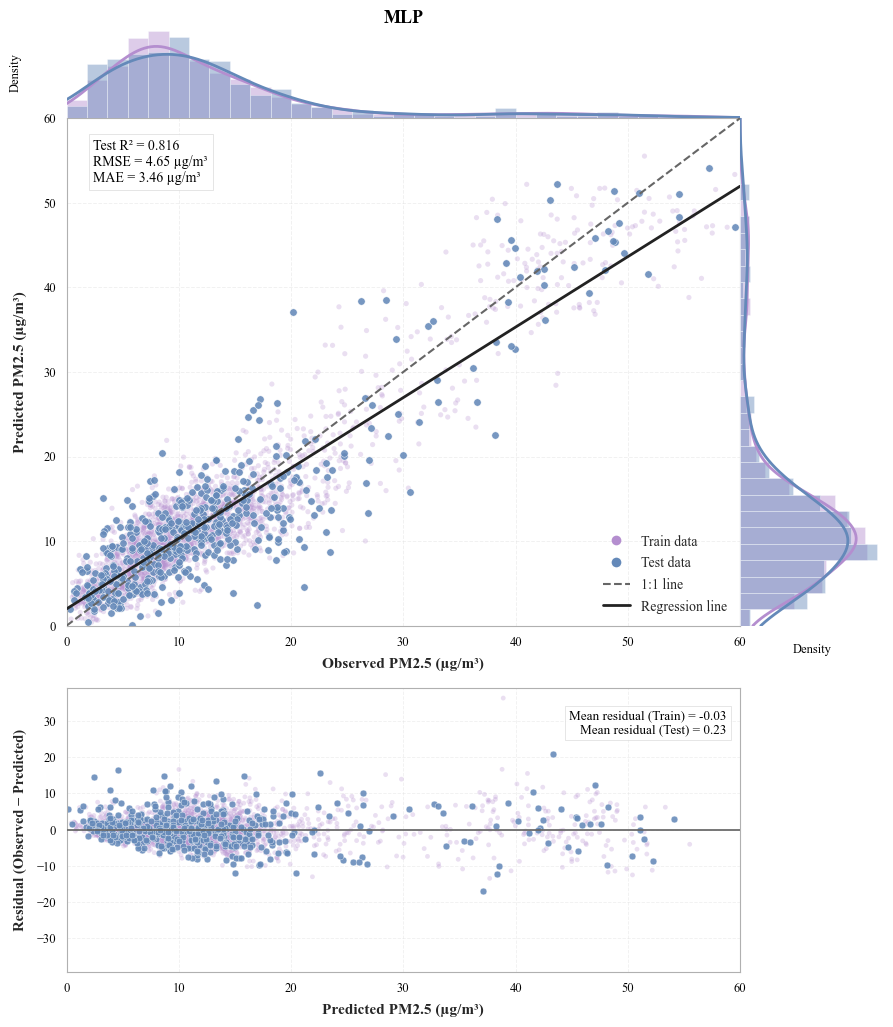

Figure saved to: /Users/qingxuan/Desktop/webcam-pm25-toolbox/results/model_benchmark/best_model_composite_diagnostics.png


In [ ]:
# Figure 5: Best-performing model diagnostics
fig_5, axes_5 = (
    benchmark_plots.plot_best_model_composite_diagnostics(
        predictions=predictions,
        fitted_models=fitted_models,
        development_df=development_df,
        features=FEATURES,
        target=TARGET,
        benchmark_results=benchmark_results,
        model_name=best_model_name,
        output_path=(
            RESULTS_DIR
            / "best_model_composite_diagnostics.png"
        ),
        figure_size=(9.5, 10.5),
        train_color="#B48ECF",
        test_color="#6489B9",
        train_alpha=0.28,
        test_alpha=0.88,
        dpi=300,
    )
)

### 3.3 Residual Distribution

The residual distribution of the top-ranked model is examined to assess the overall characteristics of prediction errors.

A distribution centred near zero with limited skewness indicates reduced systematic bias and generally consistent prediction performance.

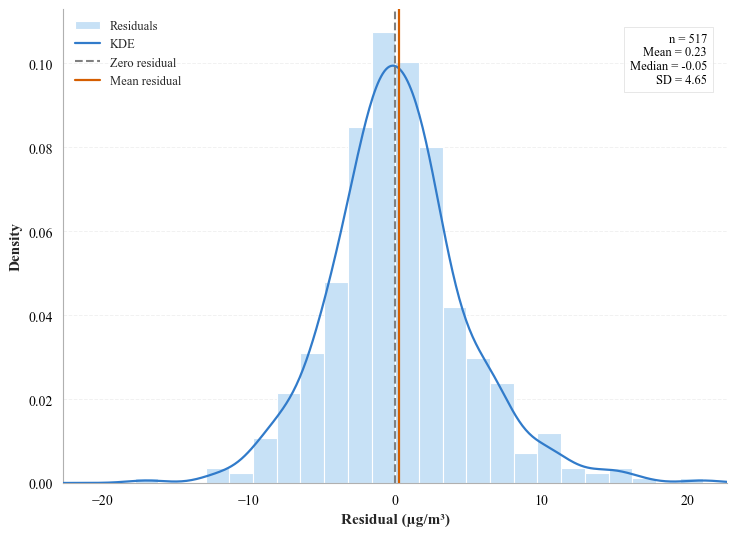

Figure saved to: /Users/qingxuan/Desktop/webcam-pm25-toolbox/results/model_benchmark/residual_distribution_best_model.png


In [113]:
# Reload plotting module
import importlib
benchmark_plots = importlib.reload(benchmark_plots)

# Figure 6: Residual distribution of the top-ranked model
fig_6, ax_6 = (
    benchmark_plots.plot_residual_distribution(
        predictions=predictions,
        model_name=best_model_name,
        output_path=(
            RESULTS_DIR
            / "residual_distribution_best_model.png"
        ),
        figure_size=(7.5, 5.5),
        histogram_color="#C7E1F6",
        density_color="#317BCA",
        zero_line_color="#808080",
        mean_line_color="#D55E00",
        bins=28,
        dpi=300,
    )
) 

## 4 Supplementary Evaluation: Chronological Split

### 4.1 Temporal Split Summary

A chronological split is used as an additional robustness evaluation to assess model performance under temporal distribution shift.

The earliest 80% of observations are used for model development, while the latest 20% are reserved for temporal testing.

This evaluation complements the primary random benchmark and is intended to examine temporal generalisation rather than overall model ranking.

In [33]:
# Sort observations chronologically
temporal_df = (
    benchmark_df
    .sort_values("time")
    .reset_index(drop=True)
)

# Create chronological development and test sets
split_index = int(
    len(temporal_df) * (1 - TEST_SIZE)
)

temporal_development_df = (
    temporal_df.iloc[:split_index]
    .copy()
)

temporal_test_df = (
    temporal_df.iloc[split_index:]
    .copy()
)

# Temporal split summary
temporal_split_summary = pd.DataFrame(
    {
        "Subset": [
            "Development set",
            "Temporal test set",
        ],
        "Samples": [
            len(temporal_development_df),
            len(temporal_test_df),
        ],
        "Start time": [
            temporal_development_df["time"].min(),
            temporal_test_df["time"].min(),
        ],
        "End time": [
            temporal_development_df["time"].max(),
            temporal_test_df["time"].max(),
        ],
        "Mean PM2.5": [
            temporal_development_df[TARGET].mean(),
            temporal_test_df[TARGET].mean(),
        ],
        "PM2.5 SD": [
            temporal_development_df[TARGET].std(),
            temporal_test_df[TARGET].std(),
        ],
    }
)

metric_columns = [
    "Mean PM2.5",
    "PM2.5 SD",
]

temporal_split_summary[metric_columns] = (
    temporal_split_summary[metric_columns]
    .round(2)
)

display(temporal_split_summary)

,Subset,Samples,Start time,End time,Mean PM2.5,PM2.5 SD
0,Development set,2064,2026-03-03 03:00:00,2026-06-17 20:00:00,13.76,12.04
1,Temporal test set,517,2026-06-17 21:00:00,2026-07-17 11:00:00,11.91,4.39


### 4.2 Random versus Chronological Performance

Model performance under the chronological split is compared with the primary random benchmark to assess the impact of temporal distribution shift.

Changes in R², RMSE, and MAE provide an indication of how well the benchmark models generalise to a later time period.

In [34]:
# Run the benchmark using the chronological split
(
    chronological_results,
    chronological_fold_results,
    chronological_fitted_models,
    chronological_predictions,
) = benchmark.benchmark_models(
    models=benchmark_models,
    development_df=temporal_development_df,
    test_df=temporal_test_df,
    features=FEATURES,
    target=TARGET,
    n_splits=N_SPLITS,
    random_state=RANDOM_STATE,
)

if chronological_results.empty:
    raise ValueError(
        "The chronological benchmark returned no results."
    )

In [35]:
# Extract random-split test performance
random_performance = benchmark_results.loc[
    :,
    [
        "Model",
        "Test R2",
        "Test RMSE",
        "Test MAE",
    ],
].rename(
    columns={
        "Test R2": "Random R2",
        "Test RMSE": "Random RMSE",
        "Test MAE": "Random MAE",
    }
)

# Extract chronological-split test performance
chronological_performance = chronological_results.loc[
    :,
    [
        "Model",
        "Test R2",
        "Test RMSE",
        "Test MAE",
    ],
].rename(
    columns={
        "Test R2": "Chronological R2",
        "Test RMSE": "Chronological RMSE",
        "Test MAE": "Chronological MAE",
    }
)

# Merge results by model
chronological_comparison = random_performance.merge(
    chronological_performance,
    on="Model",
    how="inner",
    validate="one_to_one",
)

if len(chronological_comparison) != len(benchmark_results):
    raise ValueError(
        "The random and chronological benchmark results "
        "do not contain the same models."
    )

# Calculate performance changes
chronological_comparison["R2 Change"] = (
    chronological_comparison["Chronological R2"]
    - chronological_comparison["Random R2"]
)

chronological_comparison["RMSE Change"] = (
    chronological_comparison["Chronological RMSE"]
    - chronological_comparison["Random RMSE"]
)

chronological_comparison["MAE Change"] = (
    chronological_comparison["Chronological MAE"]
    - chronological_comparison["Random MAE"]
)

# Sort by chronological test performance
chronological_comparison = (
    chronological_comparison
    .sort_values(
        by="Chronological R2",
        ascending=False,
    )
    .reset_index(drop=True)
)

# Format results for display
chronological_comparison_display = (
    chronological_comparison.copy()
)

metric_columns = [
    "Random R2",
    "Chronological R2",
    "R2 Change",
    "Random RMSE",
    "Chronological RMSE",
    "RMSE Change",
    "Random MAE",
    "Chronological MAE",
    "MAE Change",
]

chronological_comparison_display[metric_columns] = (
    chronological_comparison_display[metric_columns]
    .round(3)
)

display(chronological_comparison_display)

,Model,Random R2,Random RMSE,Random MAE,Chronological R2,Chronological RMSE,Chronological MAE,R2 Change,RMSE Change,MAE Change
0,Gradient Boosting,0.810,4.728,3.493,-0.038,4.466,3.399,-0.848,-0.262,-0.094
1,Random Forest,0.790,4.970,3.674,-0.133,4.666,3.507,-0.923,-0.304,-0.166
2,MLP,0.816,4.654,3.457,-0.503,5.374,4.080,-1.319,0.720,0.623
3,Decision Tree,0.722,5.721,4.062,-0.822,5.916,4.351,-1.543,0.194,0.290
4,Ridge,0.617,6.710,5.104,-5.083,10.810,9.507,-5.700,4.100,4.403


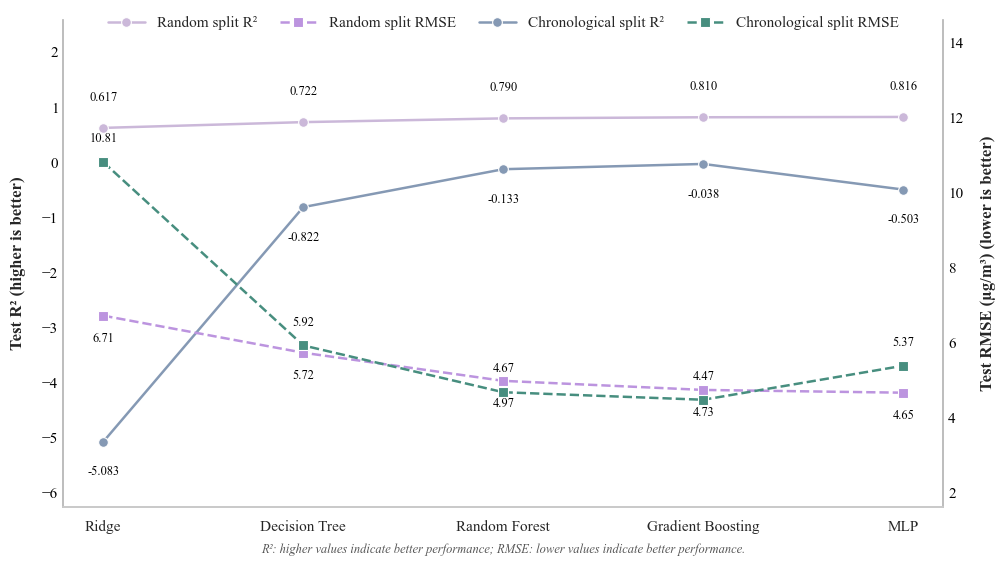

In [95]:
# Reload plotting module
import importlib
benchmark_plots = importlib.reload(benchmark_plots)

# Figure 7: Random versus chronological performance
fig_7, axes_7 = (
    benchmark_plots.plot_random_chronological_comparison(
        comparison_results=chronological_comparison,
        output_path=(
            RESULTS_DIR
            / "random_vs_chronological_performance.png"
        ),
        model_order=[
            "Ridge",
            "Decision Tree",
            "Random Forest",
            "Gradient Boosting",
            "MLP",
        ],
        figure_size=(11, 5.8),
        random_r2_color="#CBB8D9",
        random_rmse_color="#BC94DF",
        chronological_r2_color="#8599B4",
        chronological_rmse_color="#478E7F",
        dpi=300,
    )
)

## 5 Computational Efficiency

Training and prediction time are compared across the benchmark models to evaluate their computational efficiency.

Training time represents the computational cost of model fitting, while prediction time measures the time required to generate predictions for the independent test set.

Lower values indicate higher computational efficiency.

In [44]:
efficiency_summary = benchmark_results[
    [
        "Model",
        "Train Time (s)",
        "Predict Time (s)",
    ]
].copy()

efficiency_summary[
    [
        "Train Time (s)",
        "Predict Time (s)",
    ]
] = efficiency_summary[
    [
        "Train Time (s)",
        "Predict Time (s)",
    ]
].round(4)

display(efficiency_summary)

,Model,Train Time (s),Predict Time (s)
0,Ridge,0.0157,0.0099
1,Decision Tree,0.1610,0.0035
2,Random Forest,3.2134,0.0550
3,Gradient Boosting,6.3547,0.0041
4,MLP,42.4263,0.0283


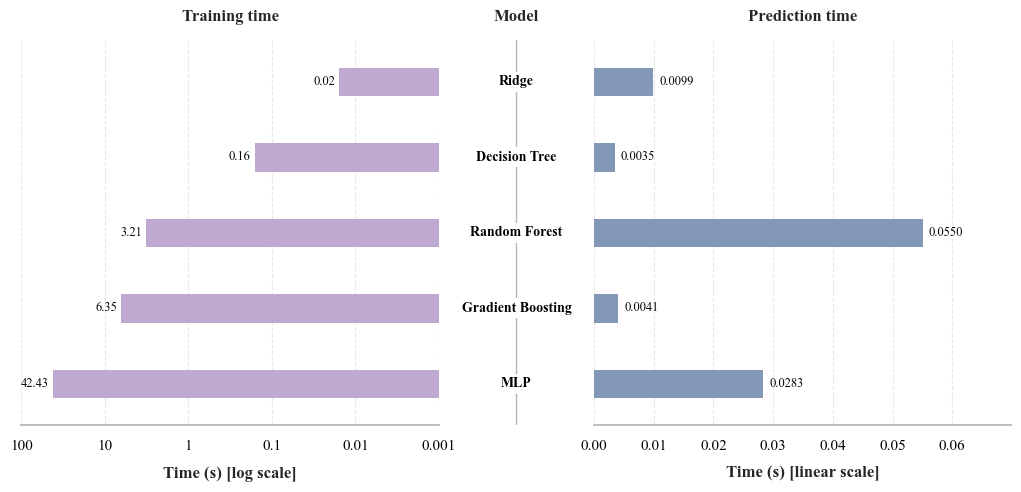

In [ ]:
# Reload plotting module
import importlib
benchmark_plots = importlib.reload(benchmark_plots)

# Figure 8: Computational efficiency of benchmark models
fig_8, axes_8 = (
    benchmark_plots.plot_computational_efficiency(
        benchmark_results=benchmark_results,
        output_path=(
            RESULTS_DIR
            / "computational_efficiency.png"
        ),
        model_order=[
            "Ridge",
            "Decision Tree",
            "Random Forest",
            "Gradient Boosting",
            "MLP",
        ],
        figure_size=(11, 5.5),
        train_color="#BFA9D1",
        predict_color="#8397B7",
        separator_color="#E0E0E0",
        center_line_color="#B5B5B5",
        bar_height=0.38,
        dpi=300,
    )
)

## 6 Benchmark Summary

The benchmark results demonstrate clear differences in predictive performance, generalisation ability, and computational efficiency across the evaluated regression models.

In [47]:
# Create benchmark summary table

best_performance_row = benchmark_results.loc[
    benchmark_results["Test R2"].idxmax()
]

fastest_training_row = benchmark_results.loc[
    benchmark_results["Train Time (s)"].idxmin()
]

fastest_prediction_row = benchmark_results.loc[
    benchmark_results["Predict Time (s)"].idxmin()
]

best_chronological_row = chronological_results.loc[
    chronological_results["Test R2"].idxmax()
]

chronological_drop = (
    best_performance_row["Test R2"]
    - best_chronological_row["Test R2"]
)

benchmark_summary = pd.DataFrame(
    {
        "Aspect": [
            "Best benchmark model",
            "Fastest training",
            "Fastest prediction",
            "Chronological evaluation",
            "Overall recommendation",
        ],
        "Result": [
            best_performance_row["Model"],
            fastest_training_row["Model"],
            fastest_prediction_row["Model"],
            "Performance degradation",
            best_performance_row["Model"],
        ],
        "Key observation": [
            (
                f"Highest independent test R² "
                f"({best_performance_row['Test R2']:.3f})"
            ),
            f"{fastest_training_row['Train Time (s)']:.4f} s",
            f"{fastest_prediction_row['Predict Time (s)']:.4f} s",
            "All models showed lower performance under temporal split.",
            "Best overall balance of accuracy and robustness.",
        ],
    }
)

display(benchmark_summary)

,Aspect,Result,Key observation
0,Best benchmark model,MLP,Highest independent test R² (0.816)
1,Fastest training,Ridge,0.0157 s
2,Fastest prediction,Decision Tree,0.0035 s
3,Chronological evaluation,Performance degradation,All models showed lower performance under temp...
4,Overall recommendation,MLP,Best overall balance of accuracy and robustness.
